# Predicting Emotions Using LLMs on IEMOCAP Data

### Install

In [1]:
%pip install "pandas<3.0.0" "python-dotenv" "openai" "google-genai" "anthropic" "scikit-learn" "seaborn" -U -q

Note: you may need to restart the kernel to use updated packages.


### Load API Keys

In [2]:
from dotenv import load_dotenv
import os

# loading variables from .env
load_dotenv() 

True

#### Gemini

In [3]:
from google import genai

client_gemini = genai.Client(
    api_key=os.getenv('GEMINI_API_KEY')
)

#### OpenAI

In [4]:
from openai import OpenAI

# Looks for an environment variable named OPENAI_API_KEY
client_openai = OpenAI()

#### Anthropic

In [5]:
import anthropic

client_claude = anthropic.Anthropic(
    api_key=os.getenv("ANTHROPIC_API_KEY")
)

### Predict Emotions

In [15]:
import json
import re

def _normalize_label(label, valid_labels):
    label = str(label).strip().lower()
    return label if label in valid_labels else "neutral"


def _extract_predictions_from_text(raw_text, expected_len, valid_labels):
    """Best-effort extraction when providers return malformed JSON."""
    if not raw_text:
        return ["neutral"] * expected_len

    text = raw_text.strip()

    # Remove markdown code fences if present.
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text)

    # First attempt: direct JSON decode.
    try:
        data = json.loads(text)
        if isinstance(data, dict):
            predictions = data.get("predictions", data.get("emotions", []))
        elif isinstance(data, list):
            predictions = data
        else:
            predictions = []

        if isinstance(predictions, list):
            cleaned = [_normalize_label(p, valid_labels) for p in predictions]
            if len(cleaned) >= expected_len:
                return cleaned[:expected_len]
    except Exception:
        pass

    # Second attempt: isolate a predictions list and pull quoted labels.
    list_match = re.search(r'"(?:predictions|emotions)"\s*:\s*\[(.*?)\]', text, re.DOTALL)
    if list_match:
        candidate = list_match.group(1)
        tokens = re.findall(r'"(angry|happy|sad|neutral)"', candidate, flags=re.IGNORECASE)
        if len(tokens) >= expected_len:
            return [_normalize_label(t, valid_labels) for t in tokens[:expected_len]]

    # Third attempt: fallback to any label tokens found in text.
    tokens = re.findall(r'\b(angry|happy|sad|neutral)\b', text, flags=re.IGNORECASE)
    if len(tokens) >= expected_len:
        return [_normalize_label(t, valid_labels) for t in tokens[:expected_len]]

    return ["neutral"] * expected_len


def predict_dialogue_emotions(client, dialogue_group, model="gpt", dialogue_id=None):
    """Sends one full dialogue and returns exactly one label per turn."""
    valid_labels = ["angry", "happy", "sad", "neutral"]

    turns = [f"Turn {i+1}: {r['utterance']}" for i, r in enumerate(dialogue_group)]
    dialogue_text = "\n".join(turns)

    prompt = f"""Task: Assign exactly one emotion label to EACH turn in the dialogue below.
Return ONLY a JSON object with key \"predictions\" and a list of labels.
The list length must be exactly {len(dialogue_group)}.

DIALOGUE TO ANALYZE:
{dialogue_text}

ALLOWED LABELS: {valid_labels}

Output format exactly:
{{"predictions": ["angry", "happy", "sad", "neutral"]}}"""

    model_key = model.lower().strip()

    try:
        if model_key == "gemini":
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=prompt,
                config={"response_mime_type": "application/json"}
            )
            raw_content = response.text or ""

        elif model_key in {"gpt", "openai"}:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": prompt}],
                response_format={"type": "json_object"},
                temperature=0.0,
                max_tokens=2048,
            )
            raw_content = (response.choices[0].message.content or "").strip()

        elif model_key == "claude":
            response = client.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=2048,
                messages=[{"role": "user", "content": prompt}],
            )
            raw_content = (response.content[0].text or "").strip()

        else:
            raise ValueError(f"Unsupported model: {model}")

        predictions = _extract_predictions_from_text(raw_content, len(dialogue_group), valid_labels)
        if len(predictions) != len(dialogue_group):
            print(f"Warning: size mismatch for dialogue {dialogue_id}. Using neutral fallback.")
            return ["neutral"] * len(dialogue_group)

        return predictions

    except Exception as e:
        print(f"Error in dialogue {dialogue_id}: {e}")
        return ["neutral"] * len(dialogue_group)

### Load IEMOCAP Data and Predict Emotions

In [11]:
import os
import pandas as pd
from tqdm.auto import tqdm

def process_iemocap_batch(client, file_path, output_csv="results.csv", model="openai"):
    df = pd.read_csv(file_path)

    processed_ids = set()
    if os.path.exists(output_csv):
        existing_df = pd.read_csv(output_csv)
        if not existing_df.empty:
            processed_ids = set(existing_df["Dialogue_ID"].unique())
            print(f"Skipping {len(processed_ids)} already processed dialogues.")

    results = []
    grouped = df.groupby("file_id")

    for diag_id, group in tqdm(grouped, desc="Processing Dialogues"):
        if diag_id in processed_ids:
            continue

        group_list = group.to_dict("records")

        try:
            predictions = predict_dialogue_emotions(
                client=client,
                dialogue_group=group_list,
                model=model,
                dialogue_id=diag_id,
            )

            curr_batch = []
            for i, row in enumerate(group_list):
                curr_batch.append({
                    "Dialogue_ID": diag_id,
                    "Utterance_ID": row["id"],
                    "Original_Emotion": row["label"],
                    "Predicted_Emotion": predictions[i] if i < len(predictions) else "neutral",
                })

            new_df = pd.DataFrame(curr_batch)
            if not os.path.isfile(output_csv):
                new_df.to_csv(output_csv, index=False)
            else:
                new_df.to_csv(output_csv, mode="a", header=False, index=False)
            results.extend(curr_batch)

        except Exception as e:
            if "429" in str(e):
                print("\nQuota hit! Saving and exiting...")
                pd.DataFrame(results).to_csv(output_csv, index=False)
                return
            print(f"Error at dialogue {diag_id}: {e}")

    return pd.DataFrame(results)

#### Predict Using Gemini 2.5 Flash

In [12]:
results_gemini = process_iemocap_batch(client_gemini, r"../../../data/iemocap_4way_data/train_unified_filtered.csv", "../../../results/4way/iemocap_llm/results_gemini.csv", "gemini")

Processing Dialogues:   1%|▏         | 1/68 [00:00<00:42,  1.59it/s]

Error in dialogue Ses02F_impro01_: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


Processing Dialogues:  10%|█         | 7/68 [01:21<11:19, 11.14s/it]

Error in dialogue Ses02F_impro07_: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


Processing Dialogues:  12%|█▏        | 8/68 [01:22<07:55,  7.92s/it]

...

Processing Dialogues:  87%|████████▋ | 59/68 [14:07<03:05, 20.59s/it]

Error in dialogue Ses04M_impro02_: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


Processing Dialogues:  91%|█████████ | 62/68 [15:06<02:02, 20.34s/it]

Error in dialogue Ses04M_impro05_: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}


Processing Dialogues: 100%|██████████| 68/68 [17:56<00:00, 15.83s/it]


#### Predict Using GPT 4o Mini

In [13]:
results_openai = process_iemocap_batch(client_openai, r"../../../data/iemocap_4way_data/train_unified_filtered.csv", "../../../results/4way/iemocap_llm/results_openai.csv", "gpt")

Processing Dialogues:   0%|          | 0/68 [00:00<?, ?it/s]

Processing Dialogues: 100%|██████████| 68/68 [12:31<00:00, 11.05s/it]


#### Predict Using Claude Sonnet 4.6

In [17]:
results_claude = process_iemocap_batch(client_claude, r"../../../data/iemocap_4way_data/train_unified_filtered.csv", "../../../results/4way/iemocap_llm/results_claude.csv", "claude")

Processing Dialogues:   0%|          | 0/68 [00:00<?, ?it/s]

Processing Dialogues: 100%|██████████| 68/68 [05:53<00:00,  5.19s/it]


### Report Results

In [2]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_results(csv_file):
    df = pd.read_csv(csv_file)
    df['Predicted_Emotion'] = df['Predicted_Emotion'].astype(str).str.strip().str.lower()
    df['Original_Emotion'] = df['Original_Emotion'].astype(str).str.strip().str.lower()
    labels = ["angry", "happy", "sad", "neutral"]

    print("--- Classification Report ---")
    # Adding zero_division=0 hides the warnings for missing labels
    print(classification_report(df['Original_Emotion'], 
                                df['Predicted_Emotion'], 
                                labels=labels,
                                zero_division=0))

    weighted_f1 = f1_score(df['Original_Emotion'], 
                           df['Predicted_Emotion'], 
                           average='weighted')
    print(f"Overall Weighted F1 Score: {weighted_f1:.4f}")
    cm = confusion_matrix(df['Original_Emotion'], 
                          df['Predicted_Emotion'], 
                          labels=labels)
    
    plt.figure(figsize=(10, 7))
    display_labels = [l.capitalize() for l in labels]
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=display_labels, yticklabels=display_labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Emotion Recognition Confusion Matrix')
    plt.show()

--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.34      0.14      0.20       704
       happy       0.61      0.22      0.32       916
         sad       0.68      0.25      0.36       645
     neutral       0.17      0.94      0.29       940

   micro avg       0.22      0.42      0.29      3205
   macro avg       0.45      0.39      0.29      3205
weighted avg       0.44      0.42      0.29      3205

Overall Weighted F1 Score: 0.1559


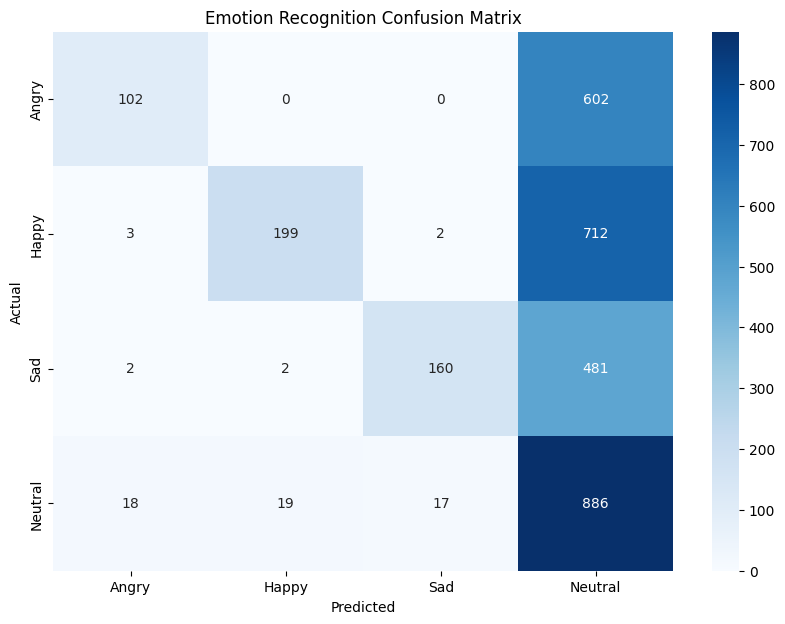

In [3]:
evaluate_results("../../../results/4way/iemocap_llm/results_gemini.csv")

--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.37      0.55      0.44       704
       happy       0.53      0.53      0.53       916
         sad       0.48      0.49      0.48       645
     neutral       0.23      0.84      0.36       940

   micro avg       0.33      0.62      0.43      3205
   macro avg       0.40      0.60      0.45      3205
weighted avg       0.40      0.62      0.45      3205

Overall Weighted F1 Score: 0.2395


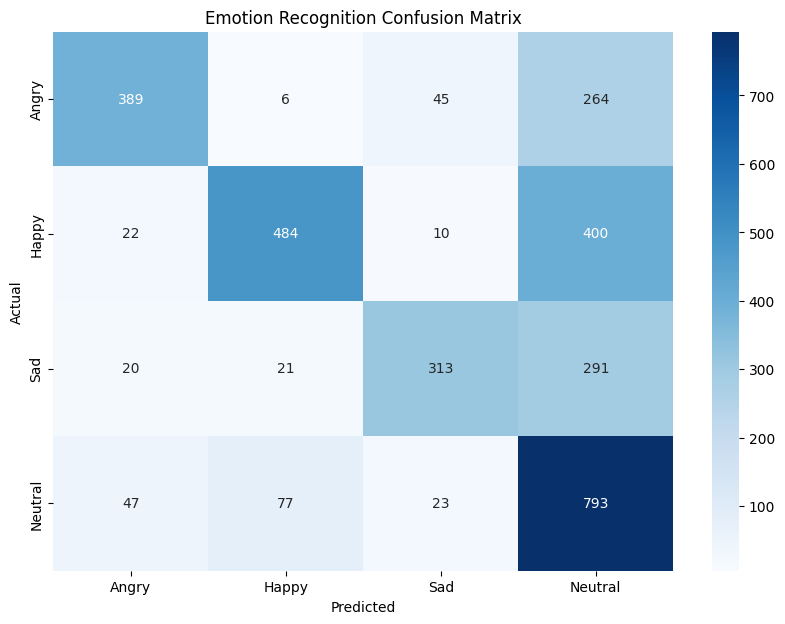

In [4]:
evaluate_results("../../../results/4way/iemocap_llm/results_claude.csv")

--- Classification Report ---
              precision    recall  f1-score   support

       angry       0.27      0.32      0.29       704
       happy       0.48      0.46      0.47       916
         sad       0.44      0.40      0.42       645
     neutral       0.17      0.68      0.27       940

   micro avg       0.26      0.48      0.33      3205
   macro avg       0.34      0.46      0.36      3205
weighted avg       0.34      0.48      0.36      3205

Overall Weighted F1 Score: 0.1924


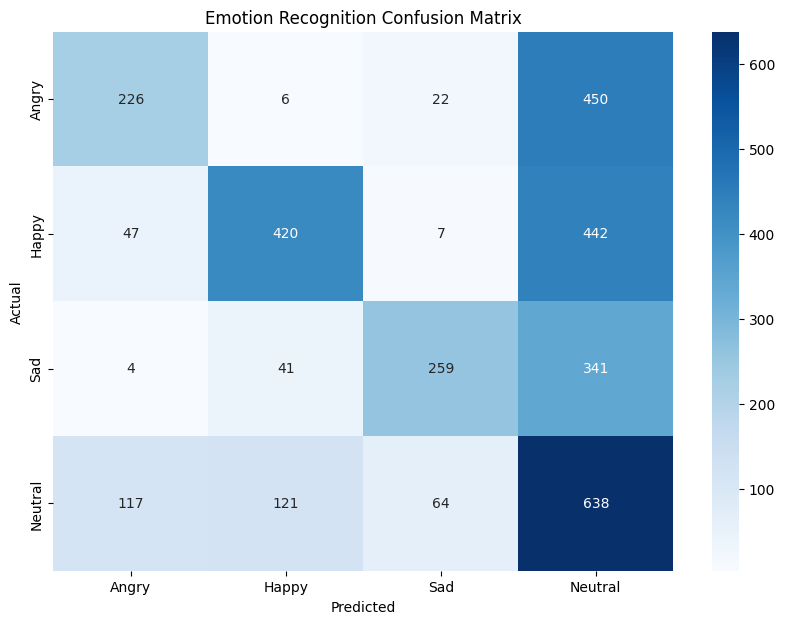

In [5]:
evaluate_results("../../../results/4way/iemocap_llm/results_openai.csv")